In [20]:
import os
import re
import zipfile
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Cấu hình giao diện đồ thị để hiển thị đẹp mắt trong Jupyter
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [21]:
zip_path = r"D:\UNI\NCKH\CTD2026_DT049\Dataset\processed\cleaned_amazon_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    csv_files = [f for f in z.namelist() if f.endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("Không tìm thấy file .csv nào trong file ZIP!")

    with z.open(csv_files[0]) as f:
        df = pd.read_csv(f)

print(f"Đã tải thành công! Kích thước: {df.shape[0]} dòng, {df.shape[1]} cột ---")

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\2867049433.py:9: DtypeWarning: Columns (0: about_item, 1: best_sellers_rank, 2: model_number, 3: product_description, 4: rating_distribution_1star, 5: rating_distribution_2star, 6: rating_distribution_3star, 7: rating_distribution_4star, 8: rating_distribution_5star, 9: recent_purchases, 10: scrape_time, 11: seller_page_url, 12: productasin, 13: productvariant, 14: reviewid, 15: reviewmetadata, 16: reviewtext, 17: reviewtitle, 18: reviewurl, 19: verifiedpurchase, 20: videos_0, 21: verified_purchases) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Đã tải thành công! Kích thước: 227695 dòng, 45 cột ---


In [36]:
# 1. DATASET PROFILE

profile = {
    "Total Rows": df.shape[0],
    "Total Columns": df.shape[1],
    "Unique Products (ASIN)": df["asin"].nunique() if "asin" in df.columns else df["productasin"].nunique(),
    "Unique Brands": df["brand_name"].nunique() if "brand_name" in df.columns else 0,
    "Unique Sellers": df["seller_name"].nunique() if "seller_name" in df.columns else 0,
    "Unique Reviews (reviewid)": df["reviewid"].nunique() if "reviewid" in df.columns else 0
}

profile_df = pd.DataFrame(list(profile.items()), columns=["Metric", "Value"])
display(profile_df)

,Metric,Value
0,Total Rows,227695
1,Total Columns,46
2,Unique Products (ASIN),162978
3,Unique Brands,284
4,Unique Sellers,268
5,Unique Reviews (reviewid),6327


In [37]:
# 2. MISSING VALUES ANALYSIS

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percent
}).sort_values(by="Missing Count", ascending=False)

# Hiển thị các cột bị thiếu dữ liệu
top_missing = missing_df[missing_df["Missing Count"] > 0]
print("\n--- Các cột thiếu dữ liệu và tỷ lệ: ---")
display(top_missing)


--- Các cột thiếu dữ liệu và tỷ lệ: ---


,Missing Count,Missing Percentage (%)
list_price,227695,100.000000
rating_count,227695,100.000000
rating_stars,227695,100.000000
videos_0,227661,99.985068
model_number,227496,99.912602
product_description,227424,99.880981
seller_page_url,227269,99.812908
rank_1,227155,99.762841
best_sellers_rank,227137,99.754935
recent_purchases,227126,99.750104


In [38]:
# 3. NUMERICAL ANALYSIS

# Chỉ định rõ các biến số cốt lõi cần phân tích
numerical_features = ["price_value", "rating", "sentiment_score", "helpful_vote"]
available_num = [col for col in numerical_features if col in df.columns]

print("\n--- Thống kê mô tả các biến số cốt lõi: ---")
display(df[available_num].describe().T)


--- Thống kê mô tả các biến số cốt lõi: ---


,count,mean,std,min,25%,50%,75%,max
price_value,227695.0,28.969791,1.513422,5.4573,28.95,28.95,28.95,249.99
rating,227459.0,3.131294,1.397192,1.0000,2.00,3.00,4.00,5.00
sentiment_score,227695.0,0.300210,0.036361,-1.0000,0.30,0.30,0.30,1.00
helpful_vote,227695.0,0.925905,5.432671,0.0000,0.00,0.00,1.00,954.00


C:\Users\trong\AppData\Local\Temp\ipykernel_15224\957701306.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_availability.values, y=top_availability.index, palette="Set2")


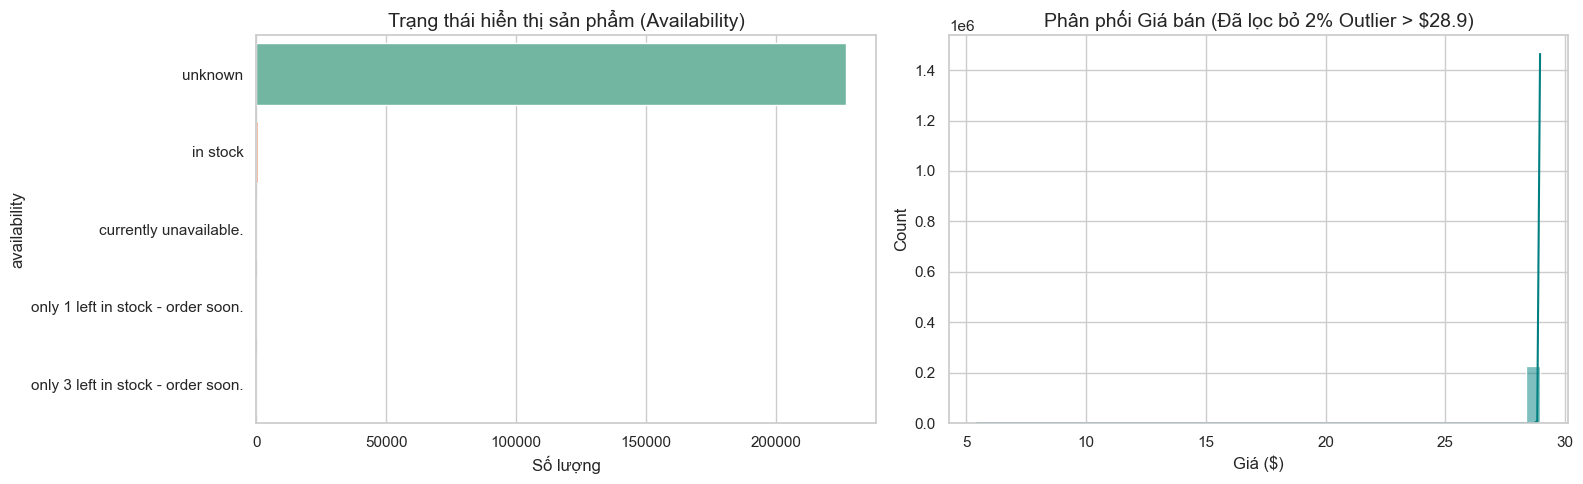

In [39]:
# 4. PRODUCT ANALYSIS

plt.figure(figsize=(16, 5))

# Đồ thị 4.1: Tình trạng hàng hóa (Availability)
plt.subplot(1, 2, 1)
if "availability" in df.columns:
    # Lấy top 5 trạng thái phổ biến nhất để tránh rối mắt
    top_availability = df["availability"].value_counts().head(5)
    sns.barplot(x=top_availability.values, y=top_availability.index, palette="Set2")
    plt.title("Trạng thái hiển thị sản phẩm (Availability)")
    plt.xlabel("Số lượng")
else:
    plt.text(0.5, 0.5, "Không tìm thấy cột availability", ha="center")

# Đồ thị 4.2: Phân phối giá thực tế (Lọc Outliers bằng phân vị 98%)
plt.subplot(1, 2, 2)
if "price_value" in df.columns and df["price_value"].notna().sum() > 0:
    price_limit = df["price_value"].quantile(0.98)
    filtered_price = df[df["price_value"] <= price_limit]["price_value"]
    
    sns.histplot(filtered_price, kde=True, color="teal", bins=40)
    plt.title(f"Phân phối Giá bán (Đã lọc bỏ 2% Outlier > ${price_limit:.1f})")
    plt.xlabel("Giá ($)")
else:
    plt.text(0.5, 0.5, "Không có dữ liệu price_value", ha="center")

plt.tight_layout()
plt.show()

Số lượng bản ghi có dữ liệu ở cột 'reviewtext': 6289
Số lượng bản ghi có dữ liệu ở cột 'text': 221139
-> Hệ thống tự động chọn thuộc tính [text] làm chủ đạo để phân tích Text Mining.


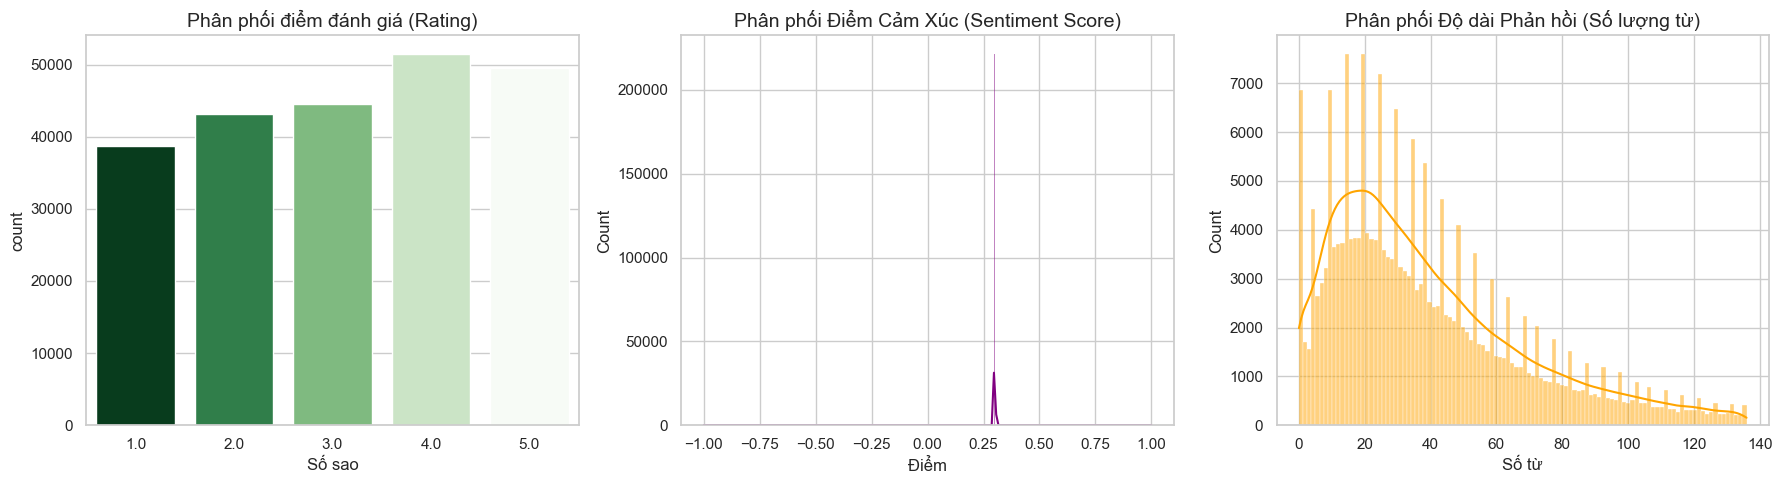


--- Top 15 từ xuất hiện nhiều nhất trong văn bản phản hồi ---


C:\Users\trong\AppData\Local\Temp\ipykernel_15224\1244302599.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Word", data=word_df, palette="GnBu_r")


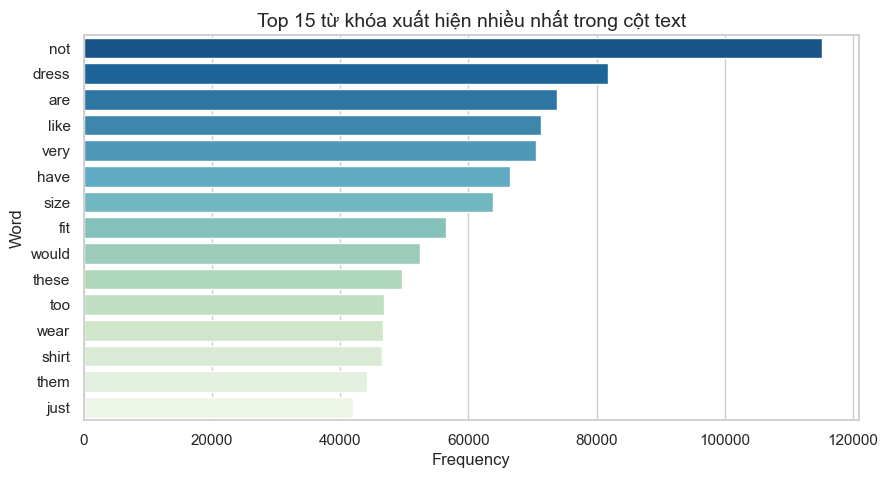

In [42]:
# 5. REVIEW ANALYSIS

# 5.1 Phân tích nguồn dữ liệu văn bản (Text vs Reviewtext)
print(f"Số lượng bản ghi có dữ liệu ở cột 'reviewtext': {df['reviewtext'].notna().sum()}")
print(f"Số lượng bản ghi có dữ liệu ở cột 'text': {df['text'].notna().sum()}")

# Chọn thuộc tính chủ đạo để phân tích độ dài và tần suất từ
text_col = "text" if df["text"].notna().sum() > df["reviewtext"].notna().sum() else "reviewtext"
print(f"-> Hệ thống tự động chọn thuộc tính [{text_col}] làm chủ đạo để phân tích Text Mining.")

# Tính độ dài từ (Word count)
df["review_length"] = df[text_col].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

# VẼ ĐỒ THỊ VĂN BẢN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Đồ thị 5.2: Phân phối điểm đánh giá (Dựa hoàn toàn vào cột rating)
if "rating" in df.columns:
    sns.countplot(x="rating", data=df, hue="rating", palette="Greens_r", ax=axes[0], legend=False)
    axes[0].set_title("Phân phối điểm đánh giá (Rating)")
    axes[0].set_xlabel("Số sao")

# Đồ thị 5.3: Phân phối điểm cảm xúc (Sentiment Score)
if "sentiment_score" in df.columns:
    sns.histplot(df["sentiment_score"].dropna(), kde=True, color="purple", ax=axes[1])
    axes[1].set_title("Phân phối Điểm Cảm Xúc (Sentiment Score)")
    axes[1].set_xlabel("Điểm")

# Đồ thị 5.4: Phân phối độ dài của phản hồi
sns.histplot(df[df["review_length"] < df["review_length"].quantile(0.95)]["review_length"], kde=True, color="orange", ax=axes[2])
axes[2].set_title("Phân phối Độ dài Phản hồi (Số lượng từ)")
axes[2].set_xlabel("Số từ")

plt.tight_layout()
plt.show()

# Đồ thị 5.5: Phân tích tần suất từ xuất hiện (Word Frequency)
print("\n--- Top 15 từ xuất hiện nhiều nhất trong văn bản phản hồi ---")
all_words = " ".join(df[text_col].astype(str).dropna()).lower()
tokens = re.findall(r"\b[a-zA-Z]{3,}\b", all_words) # Lấy từ có từ 3 chữ cái trở lên
stop_words = {"the", "and", "this", "for", "with", "that", "was", "but", "you", "they"} # Bộ từ dừng cơ bản
filtered_tokens = [w for w in tokens if w not in stop_words]

word_counts = Counter(filtered_tokens).most_common(15)
word_df = pd.DataFrame(word_counts, columns=["Word", "Frequency"])

plt.figure(figsize=(10, 5))
sns.barplot(x="Frequency", y="Word", data=word_df, palette="GnBu_r")
plt.title(f"Top 15 từ khóa xuất hiện nhiều nhất trong cột {text_col}")
plt.show()

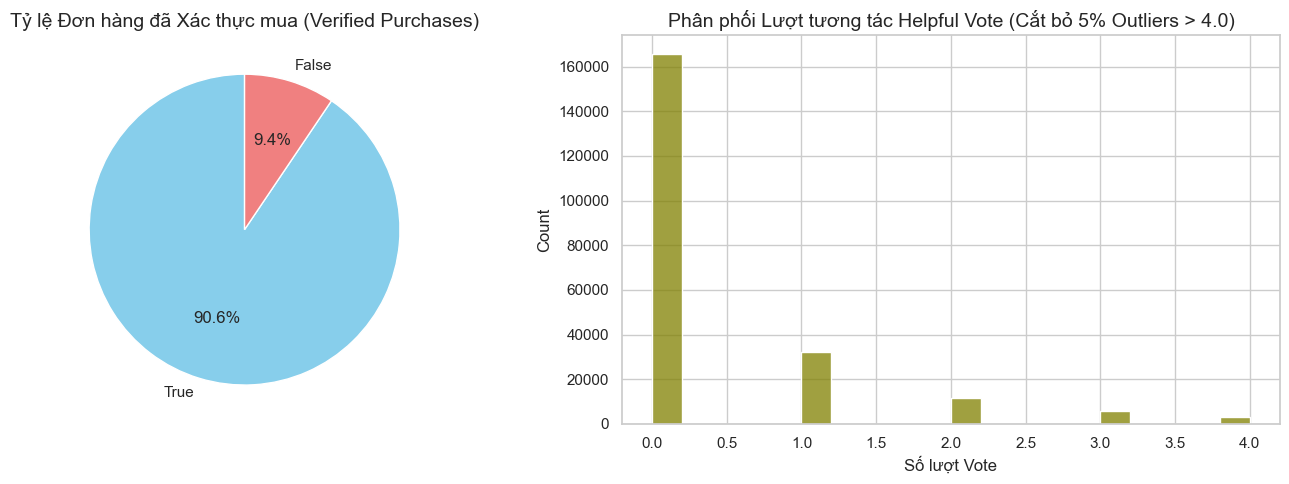

In [41]:
# 6. CUSTOMER ANALYSIS

plt.figure(figsize=(14, 5))

# Đồ thị 6.1: Tỷ lệ Tài khoản đã xác thực (Dựa trên cột lớn verified_purchases)
plt.subplot(1, 2, 1)
if "verified_purchases" in df.columns:
    verified_counts = df["verified_purchases"].value_counts()
    plt.pie(verified_counts, labels=verified_counts.index, autopct="%1.1f%%", colors=["skyblue", "lightcoral"], startangle=90)
    plt.title("Tỷ lệ Đơn hàng đã Xác thực mua (Verified Purchases)")
else:
    plt.text(0.5, 0.5, "Không tìm thấy cột verified_purchases", ha="center")

# Đồ thị 6.2: Phân tích Helpful Votes (Lượt bình chọn có ích)
plt.subplot(1, 2, 2)
if "helpful_vote" in df.columns:
    helpful_limit = df["helpful_vote"].quantile(0.95)
    sns.histplot(df[df["helpful_vote"] <= helpful_limit]["helpful_vote"], bins=20, color="olive", kde=False)
    plt.title(f"Phân phối Lượt tương tác Helpful Vote (Cắt bỏ 5% Outliers > {helpful_limit})")
    plt.xlabel("Số lượt Vote")
else:
    plt.text(0.5, 0.5, "Không tìm thấy cột helpful_vote", ha="center")

plt.tight_layout()
plt.show()

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\3804559220.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_freq.values, y=brand_freq.index, palette="viridis")


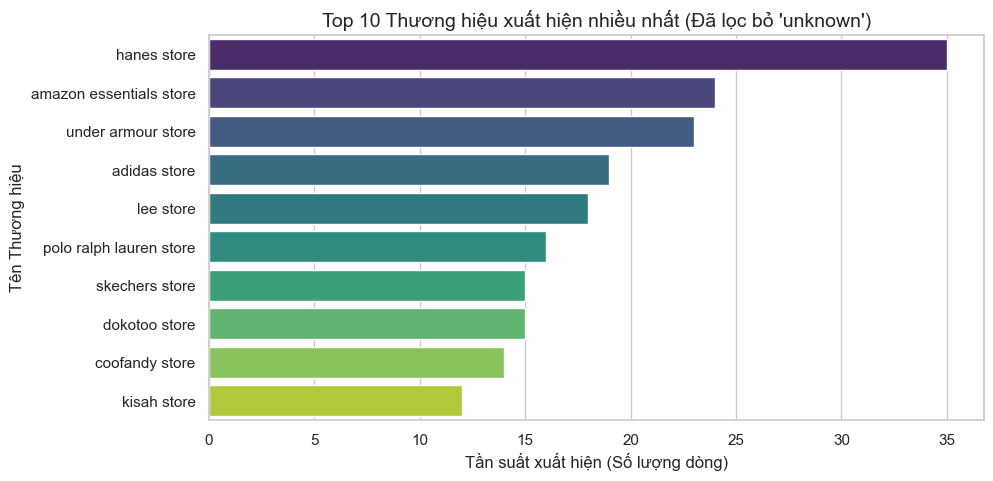

In [43]:
# 7. BRAND ANALYSIS

if "brand_name" in df.columns:
    # Lọc bỏ nhiễu unknown để đảm bảo độ chính xác cho NCKH
    clean_brands = df[~df["brand_name"].astype(str).str.lower().isin(["unknown", "nan", ""])]
    
    # Tính tần suất
    brand_freq = clean_brands["brand_name"].value_counts().head(10)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=brand_freq.values, y=brand_freq.index, palette="viridis")
    plt.title("Top 10 Thương hiệu xuất hiện nhiều nhất (Đã lọc bỏ 'unknown')")
    plt.xlabel("Tần suất xuất hiện (Số lượng dòng)")
    plt.ylabel("Tên Thương hiệu")
    plt.show()
else:
    print("Không tìm thấy cột brand_name trong dữ liệu.")


--- BẢNG THỐNG KÊ CHI TIẾT TOP 10 SELLER VS RATING & SENTIMENT ---


,Tần_suất_bản_ghi,Rating_Trung_Bình,Sentiment_Trung_Bình
seller_name,,,
amazon.com,278,4.549763,0.321518
dokotoo flagship shop,15,5.000000,0.284444
paatm shiva,15,4.800000,0.302903
kisahapparels,10,4.000000,0.290333
zity®,9,4.500000,0.303684
real essentials,9,4.750000,0.341443
coofandy,8,5.000000,0.337381
automet-us,7,5.000000,0.343502
superiorbrands,7,4.428571,0.273016


C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4247326959.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seller_subset, y="seller_name", x="rating", palette="vlag", ax=axes[0], order=top_10_sellers_names)
C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4247326959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seller_subset, y="seller_name", x="sentiment_score", palette="coolwarm", ax=axes[1], order=top_10_sellers_names)


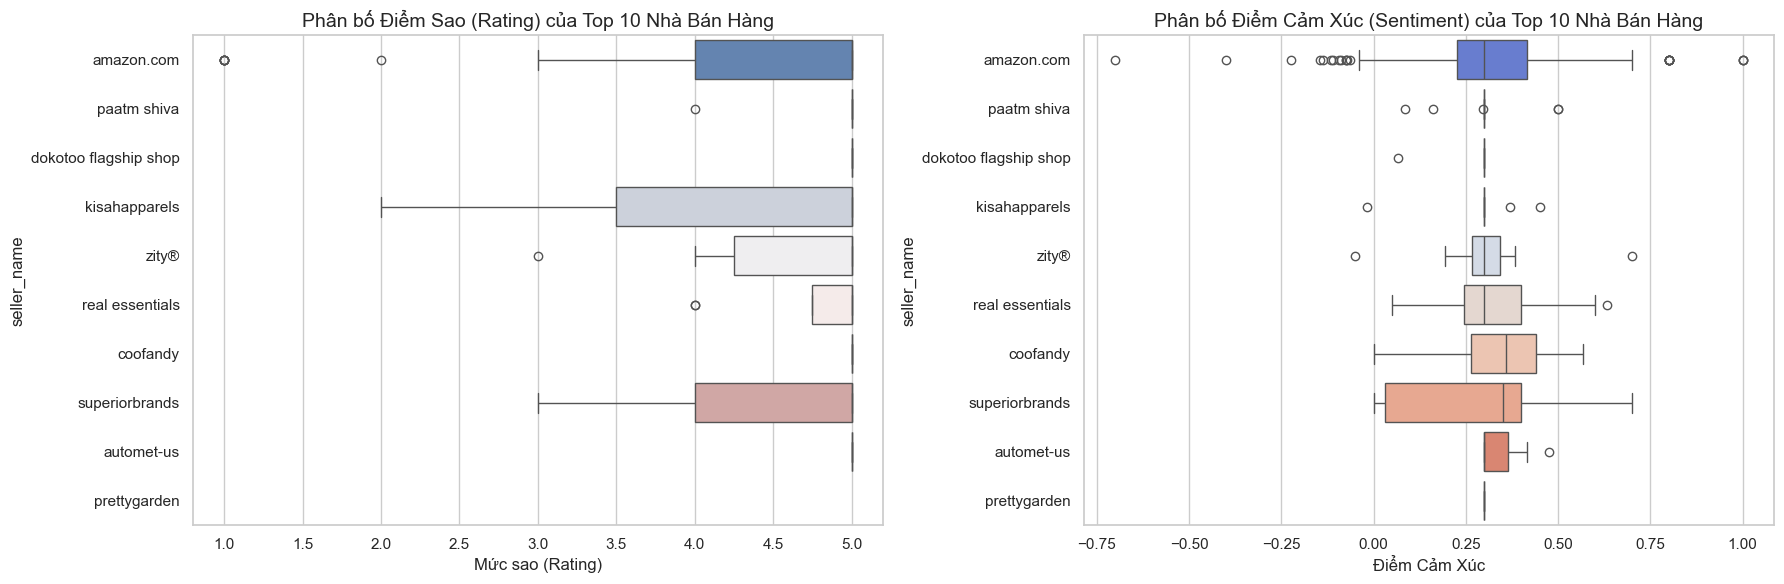

In [44]:
# 8. SELLER ANALYSIS

if "seller_name" in df.columns:
    # Lọc bỏ nhiễu unknown
    clean_sellers = df[~df["seller_name"].astype(str).str.lower().isin(["unknown", "nan", ""])]
    
    # 8.1 Top Sellers theo tần suất
    top_10_sellers_names = clean_sellers["seller_name"].value_counts().head(10).index
    seller_subset = clean_sellers[clean_sellers["seller_name"].isin(top_10_sellers_names)]
    
    # Tính toán bảng tổng hợp mối quan hệ giữa Seller và chất lượng (Rating, Sentiment)
    seller_stats = seller_subset.groupby("seller_name").agg(
        Tần_suất_bản_ghi=("seller_name", "count"),
        Rating_Trung_Bình=("rating", "mean"),
        Sentiment_Trung_Bình=("sentiment_score", "mean")
    ).sort_values(by="Tần_suất_bản_ghi", ascending=False)
    
    print("\n--- BẢNG THỐNG KÊ CHI TIẾT TOP 10 SELLER VS RATING & SENTIMENT ---")
    display(seller_stats)
    
    # TRỰC QUAN HÓA SO SÁNH
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Đồ thị 8.2: Biến thiên Rating của Top 10 Nhà bán hàng
    sns.boxplot(data=seller_subset, y="seller_name", x="rating", palette="vlag", ax=axes[0], order=top_10_sellers_names)
    axes[0].set_title("Phân bố Điểm Sao (Rating) của Top 10 Nhà Bán Hàng")
    axes[0].set_xlabel("Mức sao (Rating)")
    
    # Đồ thị 8.3: Biến thiên Sentiment Score của Top 10 Nhà bán hàng
    sns.boxplot(data=seller_subset, y="seller_name", x="sentiment_score", palette="coolwarm", ax=axes[1], order=top_10_sellers_names)
    axes[1].set_title("Phân bố Điểm Cảm Xúc (Sentiment) của Top 10 Nhà Bán Hàng")
    axes[1].set_xlabel("Điểm Cảm Xúc")
    
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy cột seller_name trong dữ liệu.")

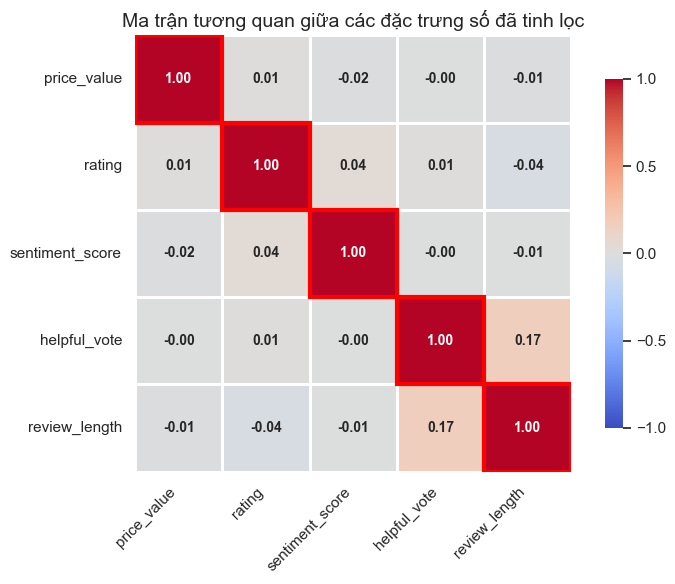

In [47]:
# 9. CORRELATION ANALYSIS

# Sử dụng danh sách các cột số thực tế có dữ liệu
final_corr_cols = [col for col in ["price_value", "rating", "sentiment_score", "helpful_vote", "review_length"] if col in df.columns]

if len(final_corr_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr_matrix = df[final_corr_cols].corr()
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        linewidths=1,
        linecolor="white",
        square=True,
        vmin=-1,
        vmax=1,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"shrink": 0.8, "ticks": [-1, -0.5, 0, 0.5, 1]}
    )
    for i in range(len(corr_matrix)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="red", lw=3))

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.title("Ma trận tương quan giữa các đặc trưng số đã tinh lọc")
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ số lượng biến số hợp lệ để lập ma trận tương quan.")

In [48]:
# 10. KEY FINDINGS SUMMARY

# Kiểm tra nhanh tỷ lệ phân phối rating_distribution để đưa vào nhận xét phản biện
rating_dist_cols = [c for c in df.columns if "rating_distribution" in c]
if rating_dist_cols:
    valid_count = df[rating_dist_cols[0]].notna().sum()
    print(f"* LƯU Ý PHẢN BIỆN: Các thuộc tính dạng 'rating_distribution' chỉ có dữ liệu chiếm tỷ lệ { (valid_count/len(df))*100 :.2f}% toàn tập dữ liệu.")

* LƯU Ý PHẢN BIỆN: Các thuộc tính dạng 'rating_distribution' chỉ có dữ liệu chiếm tỷ lệ 0.32% toàn tập dữ liệu.
